In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ratings-sample-csv/ratings_sample.csv
/kaggle/input/movielens-20m-dataset/rating.csv
/kaggle/input/movielens-20m-dataset/link.csv
/kaggle/input/movielens-20m-dataset/genome_tags.csv
/kaggle/input/movielens-20m-dataset/genome_scores.csv
/kaggle/input/movielens-20m-dataset/tag.csv
/kaggle/input/movielens-20m-dataset/movie.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load ratings
ratings = pd.read_csv(
    "/kaggle/input/movielens-20m-dataset/rating.csv",
    usecols=["userId", "movieId", "rating", "timestamp"]
)
print("Full ratings shape:", ratings.shape)

# Load movies
movies = pd.read_csv(
    "/kaggle/input/movielens-20m-dataset/movie.csv",
    usecols=["movieId", "title", "genres"]
)
print("Movies shape:", movies.shape)

# Step 1: Filter users with at least 20 ratings
user_counts = ratings["userId"].value_counts()
valid_users = user_counts[user_counts >= 20].index
filtered = ratings[ratings["userId"].isin(valid_users)]
print("After filtering low-activity users:", filtered.shape)

# Step 2: Stratified sampling by movie popularity
movie_counts = filtered["movieId"].value_counts()
filtered["popularity"] = filtered["movieId"].map(movie_counts)
filtered["pop_bin"] = pd.qcut(filtered["popularity"], q=10, duplicates="drop")

sample, _ = train_test_split(
    filtered,
    train_size=100_000,
    stratify=filtered["pop_bin"],
    random_state=42
)

# Step 3: Merge with movie metadata
sample = sample.drop(columns=["popularity", "pop_bin"]).merge(movies, on="movieId", how="left")

# Step 4: Save final sample
sample.to_csv("ratings_sample.csv", index=False)

Full ratings shape: (20000263, 4)
Movies shape: (27278, 3)
After filtering low-activity users: (20000263, 4)


In [3]:
import pandas as pd

sample = pd.read_csv("/kaggle/input/ratings-sample-csv/ratings_sample.csv")



In [4]:
print("Sampled dataset shape:", sample.shape)
print(sample.head())

Sampled dataset shape: (100000, 6)
   userId  movieId  rating            timestamp  \
0  136944      726     3.0  1996-08-01 23:32:26   
1  110425      903     4.0  2000-02-19 05:06:36   
2   41883     1027     3.0  2005-02-21 17:43:37   
3   36214       58     4.0  2000-12-01 19:12:36   
4   79066      193     4.5  2005-08-13 19:53:46   

                                  title                          genres  
0                     Last Dance (1996)                           Drama  
1                        Vertigo (1958)  Drama|Mystery|Romance|Thriller  
2  Robin Hood: Prince of Thieves (1991)                 Adventure|Drama  
3     Postman, The (Postino, Il) (1994)            Comedy|Drama|Romance  
4                      Showgirls (1995)                           Drama  


In [5]:
data = pd.merge(sample, movies, on='movieId')
print(data.head())


   userId  movieId  rating            timestamp  \
0  136944      726     3.0  1996-08-01 23:32:26   
1  110425      903     4.0  2000-02-19 05:06:36   
2   41883     1027     3.0  2005-02-21 17:43:37   
3   36214       58     4.0  2000-12-01 19:12:36   
4   79066      193     4.5  2005-08-13 19:53:46   

                                title_x                        genres_x  \
0                     Last Dance (1996)                           Drama   
1                        Vertigo (1958)  Drama|Mystery|Romance|Thriller   
2  Robin Hood: Prince of Thieves (1991)                 Adventure|Drama   
3     Postman, The (Postino, Il) (1994)            Comedy|Drama|Romance   
4                      Showgirls (1995)                           Drama   

                                title_y                        genres_y  
0                     Last Dance (1996)                           Drama  
1                        Vertigo (1958)  Drama|Mystery|Romance|Thriller  
2  Robin Hood: Princ

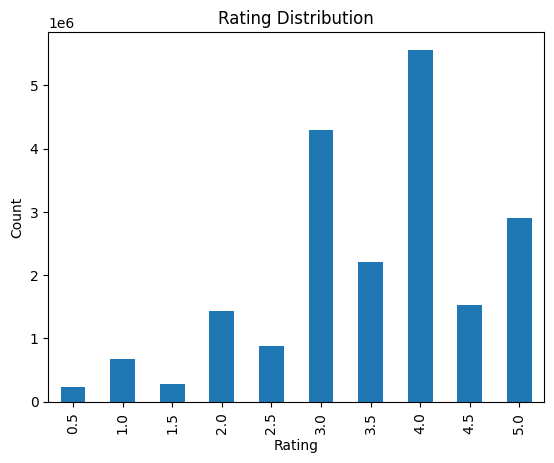

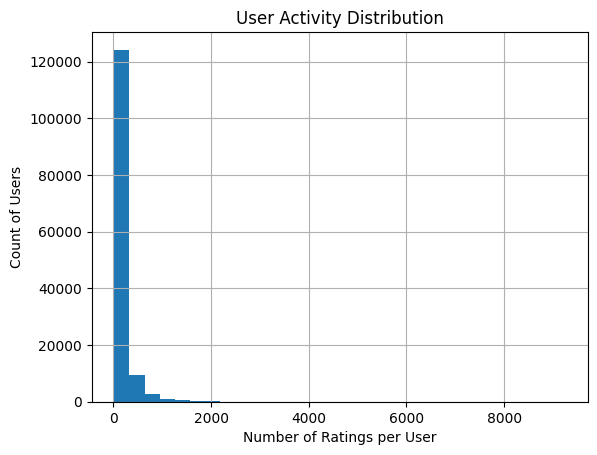

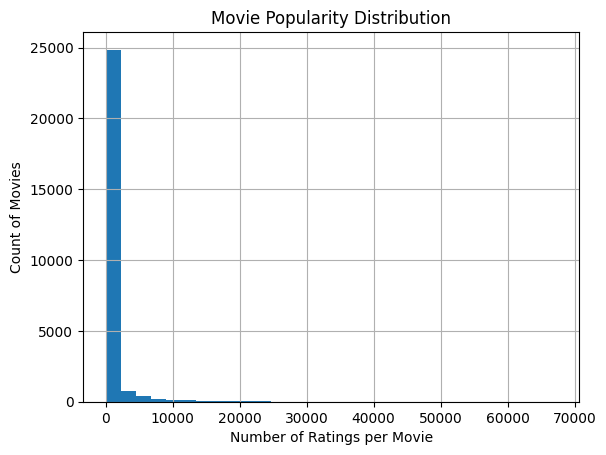

In [6]:
import matplotlib.pyplot as plt

# Rating distribution
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

# Number of ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
ratings_per_user.hist(bins=30)
plt.xlabel("Number of Ratings per User")
plt.ylabel("Count of Users")
plt.title("User Activity Distribution")
plt.show()

# Number of ratings per movie
ratings_per_movie = ratings.groupby('movieId')['rating'].count()
ratings_per_movie.hist(bins=30)
plt.xlabel("Number of Ratings per Movie")
plt.ylabel("Count of Movies")
plt.title("Movie Popularity Distribution")
plt.show()


In [7]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()
num_ratings = len(ratings)

sparsity = 1 - (num_ratings / (num_users * num_movies))
print(f"Sparsity: {sparsity:.4f}")


Sparsity: 0.9946


In [8]:
import pandas as pd

# Most popular by average rating
popular_movies = ratings.groupby("movieId").agg({"rating": "mean", "userId": "count"})
popular_movies.rename(columns={"userId": "NumRatings"}, inplace=True)
popular_movies = popular_movies.sort_values(["NumRatings", "rating"], ascending=False)

top10 = popular_movies.head(10).merge(movies, on="movieId")
print("Top 10 Popular Movies:")
print(top10[["title", "genres"]])

Top 10 Popular Movies:
                                       title                            genres
0                        Pulp Fiction (1994)       Comedy|Crime|Drama|Thriller
1                        Forrest Gump (1994)          Comedy|Drama|Romance|War
2           Shawshank Redemption, The (1994)                       Crime|Drama
3           Silence of the Lambs, The (1991)             Crime|Horror|Thriller
4                       Jurassic Park (1993)  Action|Adventure|Sci-Fi|Thriller
5  Star Wars: Episode IV - A New Hope (1977)           Action|Adventure|Sci-Fi
6                          Braveheart (1995)                  Action|Drama|War
7          Terminator 2: Judgment Day (1991)                     Action|Sci-Fi
8                         Matrix, The (1999)            Action|Sci-Fi|Thriller
9                    Schindler's List (1993)                         Drama|War


In [9]:
from sklearn.neighbors import NearestNeighbors

# User-Item matrix
user_item_matrix = sample.pivot(index="userId", columns="movieId", values="rating").fillna(0)

model_knn = NearestNeighbors(metric="cosine", algorithm="brute")
model_knn.fit(user_item_matrix)

# Example: Find neighbors of user 1
distances, indices = model_knn.kneighbors(user_item_matrix.iloc[0, :].values.reshape(1, -1), n_neighbors=6)
print("Top similar users to User 1:", indices)


Top similar users to User 1: [[    0 10303 31243 12300  1671 28280]]


In [10]:
item_item_matrix = sample.pivot(index="movieId", columns="userId", values="rating").fillna(0)

model_knn_item = NearestNeighbors(metric="cosine", algorithm="brute")
model_knn_item.fit(item_item_matrix)

# Example: Find similar movies to movie 1
distances, indices = model_knn_item.kneighbors(item_item_matrix.iloc[0, :].values.reshape(1, -1), n_neighbors=6)
print("Top similar movies to Movie 1:", indices)


Top similar movies to Movie 1: [[   0 2806 7057 7080 6295 5318]]


In [11]:


# Movies file has mapping between movieId and title

id_to_title = dict(zip(sample["movieId"], sample["title"]))
title_to_id = dict(zip(sample["title"], sample["movieId"]))

def get_similar_movies(movie_name, n=6):
    if movie_name not in title_to_id:
        return f"Movie '{movie_name}' not found in dataset."
    
    movie_id = title_to_id[movie_name]
    
    # Find index of this movie in the pivot table
    try:
        movie_idx = item_item_matrix.index.get_loc(movie_id)
    except KeyError:
        return f"Movie '{movie_name}' has no ratings in dataset."
    
    distances, indices = model_knn_item.kneighbors(
        item_item_matrix.iloc[movie_idx, :].values.reshape(1, -1), n_neighbors=n
    )
    
    similar_ids = item_item_matrix.index[indices.flatten()]
    similar_titles = [id_to_title[mid] for mid in similar_ids]
    
    return similar_titles
print(get_similar_movies("Forrest Gump (1994)", n=6))

['Forrest Gump (1994)', "Mike's New Car (2002)", 'Son of the Pink Panther (1993)', 'Bandolero! (1968)', '1776 (1972)', 'Grandview, U.S.A. (1984)']


In [12]:
import pandas as pd
from surprise import Dataset, Reader

# Load CSV
sample = pd.read_csv("/kaggle/input/ratings-sample-csv/ratings_sample.csv")

# Keep only needed columns
df = sample[['userId', 'movieId', 'rating']]

# Define rating scale
reader = Reader(rating_scale=(0.5, 5))

# Convert to Surprise dataset
data = Dataset.load_from_df(df, reader)


In [13]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2)


In [14]:
from surprise import KNNBasic, accuracy

# User-User KNN
sim_options = {'name': 'cosine', 'user_based': False}
knn_user = KNNBasic(sim_options=sim_options)
knn_user.fit(trainset)
pred_knn_user = knn_user.test(testset)

# Evaluate
accuracy.rmse(pred_knn_user)
accuracy.mae(pred_knn_user)


Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0747
MAE:  0.8569


0.8568859866261173

In [15]:
from surprise import SVD

svd = SVD(n_factors=100, biased=True, verbose=True)
svd.fit(trainset)
pred_svd = svd.test(testset)

accuracy.rmse(pred_svd)
accuracy.mae(pred_svd)


Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
RMSE: 0.9681
MAE:  0.7537


0.7536543405315786

In [16]:
from collections import defaultdict
import numpy as np

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    
    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        # Sort by estimated rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in top_k)
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in top_k)

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    
    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))
p_knn, r_knn = precision_recall_at_k(pred_knn_user, k=10)
p_svd, r_svd = precision_recall_at_k(pred_svd, k=10)

print("KNN → Precision@10:", p_knn, "Recall@10:", r_knn)
print("SVD → Precision@10:", p_svd, "Recall@10:", r_svd)



KNN → Precision@10: 0.6082304059113702 Recall@10: 0.6448081747537171
SVD → Precision@10: 0.4672377572457117 Recall@10: 0.4640529074629301


In [17]:
id_to_title = dict(zip(sample['movieId'], sample['title']))

def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        top_n[uid] = sorted(user_ratings, key=lambda x: x[1], reverse=True)[:n]
    return top_n

top_n = get_top_n(pred_svd, n=10)

# Pick a random user
user_id = list(top_n.keys())[0]
recommended = [id_to_title[iid] for (iid, _) in top_n[user_id]]
print("Recommendations for user", user_id, ":", recommended)


Recommendations for user 65387 : ['Metropolis (1927)', 'High Plains Drifter (1973)', 'Patch Adams (1998)', 'Encino Man (1992)']


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

# ----------------------------
# 1. Prepare Dataset
# ----------------------------

# Load your 100k sample
df = pd.read_csv("/kaggle/input/ratings-sample-csv/ratings_sample.csv")

In [19]:
# Map users and movies to 0-indexed IDs
user_map = {u: i for i, u in enumerate(df["userId"].unique())}
movie_map = {m: i for i, m in enumerate(df["movieId"].unique())}

df["user_idx"] = df["userId"].map(user_map)
df["movie_idx"] = df["movieId"].map(movie_map)

num_users = len(user_map)
num_movies = len(movie_map)

# Ratings – normalize (0–1) if explicit
ratings = df["rating"].values.astype(np.float32)
ratings = ratings / 5.0  # scale to [0,1]

# ----------------------------
# 2. Torch Dataset
# ----------------------------
class RatingsDataset(Dataset):
    def __init__(self, users, items, ratings):
        self.users = users
        self.items = items
        self.ratings = ratings

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.users[idx], dtype=torch.long),
            torch.tensor(self.items[idx], dtype=torch.long),
            torch.tensor(self.ratings[idx], dtype=torch.float32),
        )

dataset = RatingsDataset(df["user_idx"].values, df["movie_idx"].values, ratings)

train_loader = DataLoader(dataset, batch_size=512, shuffle=True)

In [20]:
# ----------------------------
# 3. NCF Model
# ----------------------------
class NCF(nn.Module):
    def __init__(self, num_users, num_items, emb_size=16):
        super(NCF, self).__init__()
        self.user_emb = nn.Embedding(num_users, emb_size)
        self.item_emb = nn.Embedding(num_items, emb_size)

        self.mlp = nn.Sequential(
            nn.Linear(emb_size * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()  # since ratings are scaled to [0,1]
        )

    def forward(self, user, item):
        u = self.user_emb(user)
        v = self.item_emb(item)
        x = torch.cat([u, v], dim=-1)
        return self.mlp(x).squeeze()

model1 = NCF(num_users, num_movies, emb_size=16)

# ----------------------------
# 4. Training
# ----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

epochs = 30 # start small, increase later
for epoch in range(epochs):
    model1.train()
    total_loss = 0
    for users, items, ratings_batch in train_loader:
        optimizer.zero_grad()
        preds = model1(users, items)
        loss = criterion(preds, ratings_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# ----------------------------
# 5. Recommend for a user
# ----------------------------
def recommend_for_user(user_id, top_k=10):
    model1.eval()
    user_idx = user_map[user_id]
    user_tensor = torch.tensor([user_idx] * num_movies)
    item_tensor = torch.tensor(list(range(num_movies)))

    with torch.no_grad():
        scores = model1(user_tensor, item_tensor).numpy()

    top_items = np.argsort(-scores)[:top_k]
    return [df[df["movie_idx"] == idx]["title"].iloc[0] for idx in top_items]

# Example: get recommendations for a user
print("\nRecommendations for user 136944:")
print(recommend_for_user(136944, top_k=10))

Epoch 1/30, Loss: 0.0504
Epoch 2/30, Loss: 0.0436
Epoch 3/30, Loss: 0.0422
Epoch 4/30, Loss: 0.0407
Epoch 5/30, Loss: 0.0391
Epoch 6/30, Loss: 0.0374
Epoch 7/30, Loss: 0.0357
Epoch 8/30, Loss: 0.0338
Epoch 9/30, Loss: 0.0319
Epoch 10/30, Loss: 0.0299
Epoch 11/30, Loss: 0.0279
Epoch 12/30, Loss: 0.0260
Epoch 13/30, Loss: 0.0242
Epoch 14/30, Loss: 0.0224
Epoch 15/30, Loss: 0.0207
Epoch 16/30, Loss: 0.0190
Epoch 17/30, Loss: 0.0175
Epoch 18/30, Loss: 0.0161
Epoch 19/30, Loss: 0.0148
Epoch 20/30, Loss: 0.0136
Epoch 21/30, Loss: 0.0124
Epoch 22/30, Loss: 0.0114
Epoch 23/30, Loss: 0.0104
Epoch 24/30, Loss: 0.0095
Epoch 25/30, Loss: 0.0087
Epoch 26/30, Loss: 0.0080
Epoch 27/30, Loss: 0.0074
Epoch 28/30, Loss: 0.0068
Epoch 29/30, Loss: 0.0062
Epoch 30/30, Loss: 0.0057

Recommendations for user 136944:
['Things We Lost in the Fire (2007)', '36th Chamber of Shaolin, The (Shao Lin san shi liu fang) (Master Killer) (1978)', 'Boys Town (1938)', 'Kaspar Hauser (1993)', 'Chaser, The (Chugyeogja) (200

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from sklearn.model_selection import train_test_split

# Split into train and test interactions
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Build train_pos and test_pos dictionaries
train_pos = {}
for u, m in zip(train_df["user_idx"], train_df["movie_idx"]):
    train_pos.setdefault(u, []).append(m)

test_pos = {}
for u, m in zip(test_df["user_idx"], test_df["movie_idx"]):
    test_pos.setdefault(u, []).append(m)


# Ensure every user exists in train_pos and test_pos
for u in range(num_users):
    if u not in train_pos:
        train_pos[u] = []
    if u not in test_pos:
        test_pos[u] = []

# ----------------------------
# NCF Model with dropout
# ----------------------------
class NCF(nn.Module):
    def __init__(self, num_users, num_items, emb_size=64, dropout=0.2):
        super(NCF, self).__init__()
        self.user_emb = nn.Embedding(num_users, emb_size)
        self.item_emb = nn.Embedding(num_items, emb_size)

        self.mlp = nn.Sequential(
            nn.Linear(emb_size*2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, user, item):
        u = self.user_emb(user)
        v = self.item_emb(item)
        x = torch.cat([u, v], dim=-1)
        return self.mlp(x).squeeze()

# ----------------------------
# BPR Loss
# ----------------------------
def bpr_loss(model, user, pos_item, neg_item):
    pos_score = model(user, pos_item)
    neg_score = model(user, neg_item)
    loss = -torch.mean(torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8))
    return loss

# ----------------------------
# Triplet generator
# ----------------------------
def generate_triplets(train_pos, num_users, num_items, n_samples, n_negatives=10):
    triplets = []
    users = [u for u in train_pos if len(train_pos[u]) > 0]  # only valid users
    for _ in range(n_samples):
        user = random.choice(users)
        pos_item = random.choice(train_pos[user])
        for _ in range(n_negatives):
            while True:
                neg_item = random.randint(0, num_items-1)
                if neg_item not in train_pos[user]:
                    break
            triplets.append((user, pos_item, neg_item))
    return np.array(triplets)


# ----------------------------
# Sampled evaluation
# ----------------------------
def hit_ndcg_sampled(model, train_pos, test_pos, num_users, num_items, k=10, n_neg_samples=1000):
    hits, ndcgs = [], []
    all_items = set(range(num_items))
    device = next(model.parameters()).device

    for user in test_pos.keys():
        if len(test_pos[user]) == 0:
            continue
        pos_item = test_pos[user][0]
        negatives = list(all_items - set(train_pos[user]) - {pos_item})
        if len(negatives) > n_neg_samples:
            sampled_neg = random.sample(negatives, n_neg_samples)
        else:
            sampled_neg = negatives
        items_to_rank = sampled_neg + [pos_item]
        user_tensor = torch.tensor([user]*len(items_to_rank), dtype=torch.long).to(device)
        item_tensor = torch.tensor(items_to_rank, dtype=torch.long).to(device)
        with torch.no_grad():
            scores = model(user_tensor, item_tensor).cpu().numpy()
        topk_indices = np.argsort(-scores)[:k]
        topk_items = [items_to_rank[i] for i in topk_indices]
        hit = 1 if pos_item in topk_items else 0
        ndcg = 1 / np.log2(topk_items.index(pos_item)+2) if hit else 0
        hits.append(hit)
        ndcgs.append(ndcg)
    return np.mean(hits), np.mean(ndcgs)

# ----------------------------
# Training loop with early stopping
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NCF(num_users, num_movies, emb_size=64, dropout=0.2).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

n_samples = 200_000
batch_size = 4096
n_negatives = 10
epochs = 30
best_hit10 = 0
patience = 5  # stop if no improvement for 5 evaluations
wait = 0

for epoch in range(epochs):
    triplets = generate_triplets(train_pos, num_users, num_movies, n_samples, n_negatives)
    np.random.shuffle(triplets)
    model.train()
    total_loss = 0
    num_batches = 0
    for i in range(0, len(triplets), batch_size):
        batch = triplets[i:i+batch_size]
        user = torch.as_tensor(batch[:,0], dtype=torch.long).to(device)
        pos_item = torch.as_tensor(batch[:,1], dtype=torch.long).to(device)
        neg_item = torch.as_tensor(batch[:,2], dtype=torch.long).to(device)
        optimizer.zero_grad()
        loss = bpr_loss(model, user, pos_item, neg_item)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/num_batches:.4f}")

    # Evaluate every 2 epochs
    if (epoch+1) % 2 == 0:
        hit10, ndcg10 = hit_ndcg_sampled(model, train_pos, test_pos, num_users, num_movies, k=10, n_neg_samples=1000)
        print(f"Sampled Hit@10: {hit10:.4f}, Sampled NDCG@10: {ndcg10:.4f}")

        # Early stopping based on Hit@10
        if hit10 > best_hit10:
            best_hit10 = hit10
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            print("Early stopping: no improvement in Hit@10 for", patience, "evaluations")
            break


Epoch 1/30, Loss: 0.4651
Epoch 2/30, Loss: 0.2948
Sampled Hit@10: 0.1365, Sampled NDCG@10: 0.0672
Epoch 3/30, Loss: 0.2517
Epoch 4/30, Loss: 0.2248
Sampled Hit@10: 0.1359, Sampled NDCG@10: 0.0672
Epoch 5/30, Loss: 0.2026
Epoch 6/30, Loss: 0.1827
Sampled Hit@10: 0.1277, Sampled NDCG@10: 0.0645
Epoch 7/30, Loss: 0.1657
Epoch 8/30, Loss: 0.1518
Sampled Hit@10: 0.1145, Sampled NDCG@10: 0.0577
Epoch 9/30, Loss: 0.1377
Epoch 10/30, Loss: 0.1268
Sampled Hit@10: 0.1111, Sampled NDCG@10: 0.0540
Epoch 11/30, Loss: 0.1170
Epoch 12/30, Loss: 0.1084
Sampled Hit@10: 0.1031, Sampled NDCG@10: 0.0503
Early stopping: no improvement in Hit@10 for 5 evaluations


In [32]:
ratings = df[['userId', 'movieId', 'rating']].values
import random
from collections import defaultdict

train = []
test = defaultdict(list)

for u, i, r in ratings:   # ratings is now shape (N,3)
    if random.random() < 0.1:  # 10% test
        test[int(u)].append(int(i))
    else:
        train.append((int(u), int(i), float(r)))


In [23]:
def hit_ratio(ranklist, gtItem):
    return int(gtItem in ranklist)

def ndcg_score(ranklist, gtItem):
    if gtItem in ranklist:
        index = ranklist.index(gtItem)
        return np.log(2) / np.log(index + 2)
    return 0

def evaluate_model(model1, test, user_map, movie_map, num_items, K=10):
    hits, ndcgs = [], []
    for orig_u in test:
        u = user_map[orig_u]
        for orig_i in test[orig_u]:
            i = movie_map[orig_i]
            negatives = np.random.choice(num_items, 100, replace=False)
            items = list(negatives) + [i]

            user_tensor = torch.tensor([u]*len(items))
            item_tensor = torch.tensor(items)
            with torch.no_grad():
                scores = model1(user_tensor, item_tensor).cpu().numpy().flatten()

            item_score = list(zip(items, scores))
            item_score.sort(key=lambda x: x[1], reverse=True)
            ranklist = [x[0] for x in item_score[:K]]

            hits.append(hit_ratio(ranklist, i))
            ndcgs.append(ndcg_score(ranklist, i))
    return np.mean(hits), np.mean(ndcgs)


hit10, ndcg10 = evaluate_model(model1, test, user_map, movie_map, len(movie_map), K=10)
print(f"Hit@10 = {hit10:.4f}, NDCG@10 = {ndcg10:.4f}")


Hit@10 = 0.1394, NDCG@10 = 0.0635


In [24]:
hit10, ndcg10 = evaluate_model(model, test, user_map, movie_map, len(movie_map), K=10)
print(f"Hit@10 = {hit10:.4f}, NDCG@10 = {ndcg10:.4f}")

Hit@10 = 0.6968, NDCG@10 = 0.4216


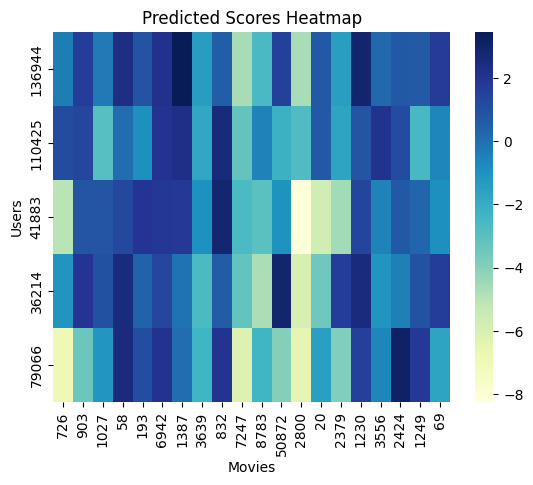

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sample_users = df['userId'].unique()[:5]
sample_movies = df['movieId'].unique()[:20]

score_matrix = np.zeros((len(sample_users), len(sample_movies)))

for i, u in enumerate(sample_users):
    u_idx = user_map[u]
    for j, m in enumerate(sample_movies):
        m_idx = movie_map[m]
        with torch.no_grad():
            score_matrix[i,j] = model(torch.tensor([u_idx]), torch.tensor([m_idx])).item()

sns.heatmap(score_matrix, xticklabels=sample_movies, yticklabels=sample_users, cmap="YlGnBu")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.title("Predicted Scores Heatmap")
plt.show()




In [26]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import torch

# ----------------------------
# 1️⃣ Prepare TF-IDF on movie genres
# ----------------------------
tfidf = TfidfVectorizer(token_pattern='[^|]+')
genre_matrix = tfidf.fit_transform(sample['genres'].fillna(''))
movie_tfidf_idx = {mid: i for i, mid in enumerate(sample['movieId'].tolist())}

# ----------------------------
# 2️⃣ Content similarity function
# ----------------------------
def content_similarity(movie_id1, movie_id2):
    idx1, idx2 = movie_tfidf_idx[movie_id1], movie_tfidf_idx[movie_id2]
    vec1, vec2 = genre_matrix[idx1], genre_matrix[idx2]
    return cosine_similarity(vec1, vec2)[0, 0]

# ----------------------------
# 3️⃣ Collaborative Filtering (BPR-NCF) score
# ----------------------------
def cf_score(user_id, movie_id, model, device='cpu'):
    model.eval()
    user_tensor = torch.tensor([user_map[user_id]], dtype=torch.long).to(device)
    movie_tensor = torch.tensor([movie_map[movie_id]], dtype=torch.long).to(device)
    with torch.no_grad():
        score = model(user_tensor, movie_tensor).item()
    return score

# ----------------------------
# 4️⃣ Hybrid score: combine CF + content
# ----------------------------
def hybrid_score(user_id, movie_id, model, cf_weight=0.7, device='cpu'):
    # CF score from BPR-NCF
    cf_s = cf_score(user_id, movie_id, model, device)

    # Content score: average similarity with user's rated movies
    user_movies = sample[sample['userId'] == user_id]['movieId'].tolist()
    if user_movies:
        content_scores = [content_similarity(m, movie_id) for m in user_movies if m in movie_tfidf_idx]
        content_s = np.mean(content_scores) if content_scores else 0
    else:
        content_s = 0
    

    # Weighted hybrid score
    return cf_weight * cf_s + (1 - cf_weight) * content_s 
    
   

In [27]:
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# ----------------------------
# GPU-accelerated hybrid with diversity
# ----------------------------
def recommend_hybrid_diverse(user_id, top_n=10, top_k_ref=2, model=None, cf_weight=0.7, device='cpu', pop_penalty=True, candidate_k=100):
    model.eval()
    all_movies = sample['movieId'].unique()
    user_rated = sample[sample['userId'] == user_id]['movieId'].values

    # 1️⃣ Candidate selection: pick top-k most similar to user's rated movies (content-based)
    candidates = set()
    for m in user_rated:
        sims = [(mid, content_similarity(m, mid)) for mid in all_movies if mid not in user_rated and mid in movie_tfidf_idx]
        sims.sort(key=lambda x: x[1], reverse=True)
        candidates.update([mid for mid, _ in sims[:candidate_k]])
    candidates = list(candidates)
    if not candidates:
        return []

    # 2️⃣ Vectorized CF scoring
    user_tensor = torch.tensor([user_map[user_id]] * len(candidates), dtype=torch.long).to(device)
    movie_tensor = torch.tensor([movie_map[m] for m in candidates], dtype=torch.long).to(device)
    with torch.no_grad():
        cf_scores = model(user_tensor, movie_tensor).cpu().numpy()

    # 3️⃣ Content scores
    content_scores = []
    for m in candidates:
        user_movies = [um for um in user_rated if um in movie_tfidf_idx]
        if user_movies:
            sims = [content_similarity(um, m) for um in user_movies]
            content_scores.append(np.mean(sims) if sims else 0)
        else:
            content_scores.append(0)
    content_scores = np.array(content_scores)

    # 4️⃣ Popularity penalty (optional)
    if pop_penalty:
        popularity = sample.groupby('movieId').size().to_dict()
        pop_scores = np.array([1 / (np.log(1 + popularity[m])) for m in candidates])
    else:
        pop_scores = np.zeros(len(candidates))

    # 5️⃣ Weighted hybrid score
    hybrid_scores = cf_weight * cf_scores + (1 - cf_weight) * content_scores + 0.1 * pop_scores  # 0.1 for pop penalty weight

    # 6️⃣ Top-N selection
    top_idx = np.argsort(-hybrid_scores)[:top_n]
    recommendations = []
    for i in top_idx:
        movie_id = candidates[i]
        h_score = round(hybrid_scores[i], 3)

        # Content-based explanation
        if len(user_rated) > 0:
            similarities = [(m, content_similarity(m, movie_id)) for m in user_rated if m in movie_tfidf_idx]
            similarities.sort(key=lambda x: x[1], reverse=True)
            top_refs = similarities[:top_k_ref]
            ref_strings = [f"{sample[sample['movieId']==m]['title'].values[0]} (sim={sim:.2f})" for m, sim in top_refs]
            explanation = "Because you liked " + " and ".join(ref_strings)
        else:
            explanation = "Recommended based on your preferences"

        recommendations.append((sample[sample['movieId']==movie_id]['title'].values[0], explanation, h_score))

    return recommendations
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

valid_user_id = sample['userId'].iloc[202]  # pick a real user
recommendations = recommend_hybrid_diverse(user_id=valid_user_id, top_n=10, model=model, cf_weight=0.7, device=device)

for title, explanation, score in recommendations:
    print(title, score)
    print(explanation)





Good Will Hunting (1997) 1.805
Because you liked Last Tango in Paris (Ultimo tango a Parigi) (1972) (sim=1.00) and Hamlet (1948) (sim=0.56)
Chocolat (2000) 1.618
Because you liked Last Tango in Paris (Ultimo tango a Parigi) (1972) (sim=1.00) and Hamlet (1948) (sim=0.56)
Star Trek: Generations (1994) 1.397
Because you liked Altered States (1980) (sim=0.80) and Hamlet (1948) (sim=0.43)
Natural Born Killers (1994) 1.297
Because you liked Dirty Harry (1971) (sim=1.00) and Good, the Bad and the Ugly, The (Buono, il brutto, il cattivo, Il) (1966) (sim=0.20)
Truman Show, The (1998) 1.274
Because you liked Altered States (1980) (sim=0.86) and Hamlet (1948) (sim=0.46)
Stealing Beauty (1996) 1.258
Because you liked Hamlet (1948) (sim=1.00) and Last Tango in Paris (Ultimo tango a Parigi) (1972) (sim=0.56)
Die Hard: With a Vengeance (1995) 1.196
Because you liked Dirty Harry (1971) (sim=1.00) and Good, the Bad and the Ugly, The (Buono, il brutto, il cattivo, Il) (1966) (sim=0.20)
Fight Club (1999)

In [1]:
import numpy as np
import pandas as pd
from surprise import Dataset, Reader, KNNBasic, SVD
from collections import defaultdict
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics.pairwise import cosine_similarity

# ============================================
# HELPER: Content Similarity (cached)
# ============================================

def precompute_content_similarities(movie_map, genre_matrix, movie_tfidf_idx):
    """Precompute pairwise similarities to speed up hybrid"""
    print("Precomputing content similarities...")
    n_movies = len(movie_map)
    sim_matrix = cosine_similarity(genre_matrix)
    
    # Map from movie_map indices to tfidf indices
    idx_map = {}
    for movie_id, map_idx in movie_map.items():
        if movie_id in movie_tfidf_idx:
            idx_map[map_idx] = movie_tfidf_idx[movie_id]
    
    return sim_matrix, idx_map

# ============================================
# COMPLETE EVALUATION WITH HYBRID
# ============================================

def evaluate_all_models_with_hybrid(sample, user_map, movie_map, ncf_model, test, 
                                   genre_matrix, movie_tfidf_idx, device='cpu'):
    """
    Evaluate all models including optimized hybrid
    """
    
    print("\n" + "="*70)
    print("MODEL COMPARISON (100 Negatives + Hybrid)".center(70))
    print("="*70 + "\n")
    
    num_items = len(movie_map)
    results = []
    
    # Precompute for hybrid
    sim_matrix, idx_map = precompute_content_similarities(movie_map, genre_matrix, movie_tfidf_idx)
    
    # Prepare Surprise training data
    train_data = []
    all_ratings = sample[['userId', 'movieId', 'rating']].values
    test_items = set()
    for u in test:
        test_items.update(test[u])
    
    for u, i, r in all_ratings:
        if int(i) not in test_items:
            train_data.append([int(u), int(i), float(r)])
    
    train_df = pd.DataFrame(train_data, columns=['userId', 'movieId', 'rating'])
    reader = Reader(rating_scale=(0.5, 5))
    data = Dataset.load_from_df(train_df, reader)
    trainset = data.build_full_trainset()
    
    # Build reverse map: movie_map_idx -> movieId
    idx_to_movie = {v: k for k, v in movie_map.items()}
    
    # ========== 1. POPULARITY ==========
    print("1/5 Popularity Baseline...")
    pop_start = time.time()
    
    item_popularity = sample['movieId'].value_counts().to_dict()
    
    hits, ndcgs = [], []
    for orig_u in test:
        for orig_i in test[orig_u]:
            i = movie_map[orig_i]
            negatives = np.random.choice(num_items, 100, replace=False)
            items = list(negatives) + [i]
            
            scores = []
            for item in items:
                movie_id = idx_to_movie.get(item, item)
                scores.append(item_popularity.get(movie_id, 0))
            
            item_score = list(zip(items, scores))
            item_score.sort(key=lambda x: x[1], reverse=True)
            ranklist = [x[0] for x in item_score[:10]]
            
            hits.append(1 if i in ranklist else 0)
            if i in ranklist:
                ndcgs.append(np.log(2) / np.log(ranklist.index(i) + 2))
            else:
                ndcgs.append(0)
    
    pop_time = (time.time() - pop_start) / len(hits) * 1000
    results.append({
        'Model': 'Popularity',
        'Hit@10': np.mean(hits),
        'NDCG@10': np.mean(ndcgs),
        'Time (ms)': pop_time
    })
    print(f"   Hit@10: {np.mean(hits):.4f}, NDCG@10: {np.mean(ndcgs):.4f}")
    
    # ========== 2. KNN ==========
    print("2/5 KNN Collaborative Filtering...")
    knn_start = time.time()
    knn = KNNBasic(sim_options={'name': 'cosine', 'user_based': False})
    knn.fit(trainset)
    
    hits, ndcgs = [], []
    for orig_u in test:
        for orig_i in test[orig_u]:
            i = movie_map[orig_i]
            negatives = np.random.choice(num_items, 100, replace=False)
            items = list(negatives) + [i]
            
            scores = []
            for item in items:
                movie_id = idx_to_movie.get(item, item)
                try:
                    scores.append(knn.predict(orig_u, movie_id).est)
                except:
                    scores.append(3.0)
            
            item_score = list(zip(items, scores))
            item_score.sort(key=lambda x: x[1], reverse=True)
            ranklist = [x[0] for x in item_score[:10]]
            
            hits.append(1 if i in ranklist else 0)
            if i in ranklist:
                ndcgs.append(np.log(2) / np.log(ranklist.index(i) + 2))
            else:
                ndcgs.append(0)
    
    knn_time = (time.time() - knn_start) / len(hits) * 1000
    results.append({
        'Model': 'KNN-CF',
        'Hit@10': np.mean(hits),
        'NDCG@10': np.mean(ndcgs),
        'Time (ms)': knn_time
    })
    print(f"   Hit@10: {np.mean(hits):.4f}, NDCG@10: {np.mean(ndcgs):.4f}")
    
    # ========== 3. SVD ==========
    print("3/5 SVD Matrix Factorization...")
    svd_start = time.time()
    svd = SVD(n_factors=100, biased=True, random_state=42, verbose=False)
    svd.fit(trainset)
    
    hits, ndcgs = [], []
    for orig_u in test:
        for orig_i in test[orig_u]:
            i = movie_map[orig_i]
            negatives = np.random.choice(num_items, 100, replace=False)
            items = list(negatives) + [i]
            
            scores = []
            for item in items:
                movie_id = idx_to_movie.get(item, item)
                try:
                    scores.append(svd.predict(orig_u, movie_id).est)
                except:
                    scores.append(3.0)
            
            item_score = list(zip(items, scores))
            item_score.sort(key=lambda x: x[1], reverse=True)
            ranklist = [x[0] for x in item_score[:10]]
            
            hits.append(1 if i in ranklist else 0)
            if i in ranklist:
                ndcgs.append(np.log(2) / np.log(ranklist.index(i) + 2))
            else:
                ndcgs.append(0)
    
    svd_time = (time.time() - svd_start) / len(hits) * 1000
    results.append({
        'Model': 'SVD',
        'Hit@10': np.mean(hits),
        'NDCG@10': np.mean(ndcgs),
        'Time (ms)': svd_time
    })
    print(f"   Hit@10: {np.mean(hits):.4f}, NDCG@10: {np.mean(ndcgs):.4f}")
    
    # ========== 4. NCF ==========
    print("4/5 Neural Collaborative Filtering (BPR)...")
    ncf_start = time.time()
    
    hits, ndcgs = [], []
    ncf_model.eval()
    
    for orig_u in test:
        u = user_map[orig_u]
        for orig_i in test[orig_u]:
            i = movie_map[orig_i]
            negatives = np.random.choice(num_items, 100, replace=False)
            items = list(negatives) + [i]
            
            user_tensor = torch.tensor([u]*len(items), dtype=torch.long).to(device)
            item_tensor = torch.tensor(items, dtype=torch.long).to(device)
            
            with torch.no_grad():
                scores = ncf_model(user_tensor, item_tensor).cpu().numpy().flatten()
            
            item_score = list(zip(items, scores))
            item_score.sort(key=lambda x: x[1], reverse=True)
            ranklist = [x[0] for x in item_score[:10]]
            
            hits.append(1 if i in ranklist else 0)
            if i in ranklist:
                ndcgs.append(np.log(2) / np.log(ranklist.index(i) + 2))
            else:
                ndcgs.append(0)
    
    ncf_time = (time.time() - ncf_start) / len(hits) * 1000
    results.append({
        'Model': 'NCF (BPR)',
        'Hit@10': np.mean(hits),
        'NDCG@10': np.mean(ndcgs),
        'Time (ms)': ncf_time
    })
    print(f"   Hit@10: {np.mean(hits):.4f}, NDCG@10: {np.mean(ndcgs):.4f}")
    
    # ========== 5. HYBRID (OPTIMIZED) ==========
    print("5/5 Hybrid (CF + Content - Optimized)...")
    hybrid_start = time.time()
    
    hits, ndcgs = [], []
    cf_weight = 0.7
    
    for orig_u in test:
        u = user_map[orig_u]
        # Get user's rated items for content similarity
        user_items = sample[sample['userId'] == orig_u]['movieId'].values
        user_item_indices = [movie_map[m] for m in user_items if m in movie_map]
        
        for orig_i in test[orig_u]:
            i = movie_map[orig_i]
            negatives = np.random.choice(num_items, 100, replace=False)
            items = list(negatives) + [i]
            
            # CF scores
            user_tensor = torch.tensor([u]*len(items), dtype=torch.long).to(device)
            item_tensor = torch.tensor(items, dtype=torch.long).to(device)
            
            with torch.no_grad():
                cf_scores = ncf_model(user_tensor, item_tensor).cpu().numpy().flatten()
            
            # Content scores (vectorized using precomputed similarities)
            content_scores = np.zeros(len(items))
            for idx, item in enumerate(items):
                if item in idx_map:
                    # Average similarity to user's rated items
                    sims = []
                    for user_item in user_item_indices[:10]:  # Limit to 10 for speed
                        if user_item in idx_map:
                            sim = sim_matrix[idx_map[item], idx_map[user_item]]
                            sims.append(sim)
                    content_scores[idx] = np.mean(sims) if sims else 0
            
            # Hybrid score
            scores = cf_weight * cf_scores + (1 - cf_weight) * content_scores
            
            item_score = list(zip(items, scores))
            item_score.sort(key=lambda x: x[1], reverse=True)
            ranklist = [x[0] for x in item_score[:10]]
            
            hits.append(1 if i in ranklist else 0)
            if i in ranklist:
                ndcgs.append(np.log(2) / np.log(ranklist.index(i) + 2))
            else:
                ndcgs.append(0)
    
    hybrid_time = (time.time() - hybrid_start) / len(hits) * 1000
    results.append({
        'Model': 'Hybrid (CF+Content)',
        'Hit@10': np.mean(hits),
        'NDCG@10': np.mean(ndcgs),
        'Time (ms)': hybrid_time
    })
    print(f"   Hit@10: {np.mean(hits):.4f}, NDCG@10: {np.mean(ndcgs):.4f}")
    
    return pd.DataFrame(results)

# ============================================
# VISUALIZATION
# ============================================

def plot_final_comparison(results_df):
    """Create publication-ready visualization"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    models = results_df['Model']
    colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#feca57']
    
    # Plot 1: Hit@10 and NDCG@10
    ax1 = axes[0]
    x = np.arange(len(models))
    width = 0.35
    ax1.bar(x - width/2, results_df['Hit@10'], width, label='Hit@10', alpha=0.8, color='steelblue')
    ax1.bar(x + width/2, results_df['NDCG@10'], width, label='NDCG@10', alpha=0.8, color='coral')
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('Ranking Metrics', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=30, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Improvement
    ax2 = axes[1]
    baseline = results_df.iloc[0]['Hit@10']
    improvements = [(row['Hit@10'] - baseline) / baseline * 100 for _, row in results_df.iterrows()]
    bars = ax2.bar(models, improvements, alpha=0.8, color=colors, edgecolor='black')
    ax2.set_ylabel('% Improvement', fontsize=12, fontweight='bold')
    ax2.set_title('Hit@10 Lift over Baseline', fontsize=14, fontweight='bold')
    ax2.set_xticklabels(models, rotation=30, ha='right')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax2.grid(axis='y', alpha=0.3)
    
    # Highlight best
    best_idx = np.argmax(improvements)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    
    # Plot 3: Efficiency
    ax3 = axes[2]
    ax3.barh(models, results_df['Time (ms)'], alpha=0.8, color=colors, edgecolor='black')
    ax3.set_xlabel('Time (ms per user)', fontsize=12, fontweight='bold')
    ax3.set_title('Inference Efficiency', fontsize=14, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('final_comparison_with_hybrid.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# RUN EVERYTHING
# ============================================

results = evaluate_all_models_with_hybrid(
    sample, user_map, movie_map, model, test,
    genre_matrix, movie_tfidf_idx, device=device
)

# Display
print("\n" + "="*80)
print("FINAL MODEL COMPARISON (With Hybrid)".center(80))
print("="*80 + "\n")

display = results.copy()
display['Hit@10'] = (display['Hit@10'] * 100).round(2).astype(str) + '%'
display['NDCG@10'] = display['NDCG@10'].round(4)
display['Time (ms)'] = display['Time (ms)'].round(2)

print(display.to_string(index=False))
print("\n" + "="*80)

# Key insights
baseline_hit = results.iloc[0]['Hit@10']
best_idx = results['Hit@10'].idxmax()
best_model = results.iloc[best_idx]['Model']
best_hit = results.iloc[best_idx]['Hit@10']
improvement = ((best_hit - baseline_hit) / baseline_hit) * 100

print(f"\nKey Results:")
print(f"  - {best_model} achieves {improvement:.1f}% improvement over baseline")
print(f"  - Hit@10: {best_hit:.4f} vs Baseline: {baseline_hit:.4f}")
print("="*80 + "\n")

# Visualize
plot_final_comparison(results)

# Save
results.to_csv('final_comparison_with_hybrid.csv', index=False)
print("Saved: 'final_comparison_with_hybrid.csv' and 'final_comparison_with_hybrid.png'")

KeyboardInterrupt: 

In [29]:
# Save the PyTorch CF model
torch.save(model.state_dict(), "ncf_model.pth")

# Save mappings and TF-IDF vectorizer so the app can interpret inputs
import joblib
joblib.dump(user_map, "user_map.pkl")
joblib.dump(movie_map, "movie_map.pkl")
joblib.dump(movie_tfidf_idx, "movie_tfidf_idx.pkl")
joblib.dump(genre_matrix, "tfidf.pkl")

# Save your movies DataFrame (titles, genres, indices)
sample[["movieId", "title", "genres"]].to_csv("movies.csv", index=False)